## Setup

In [1]:
!pip install numpy tensorflow scikit-learn matplotlib pillow seaborn

In [2]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import time
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
train_dir = "Traffic_Sign/Train"
test_dir  = "Traffic_Sign/Test"

In [5]:
print(tf.config.list_physical_devices('GPU'))
print(tf.test.gpu_device_name())

[]



In [6]:
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(4)
print("Running on CPU with optimized threading.")

Running on CPU with optimized threading.


## Data Understanding, Analysis, Visualization and Cleaning

#### Get Class Names

In [7]:
def get_class_names(directory):
    class_names = sorted(os.listdir(directory))
    if not class_names:
        print("No class directories found!")
    else:
        print(f"Found {len(class_names)} classes: {class_names}")

print("For train directory")
get_class_names(train_dir)

For train directory
Found 4 classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


### Check Corrupt image

In [8]:
def check_corrupt_images(directory):
    corrupted_images = []
    class_names = sorted(os.listdir(directory))
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except (IOError, UnidentifiedImageError):
                    corrupted_images.append(img_path)
    if corrupted_images:
        print(f"\nCorrupted Images Found in {directory}:")
        for img in corrupted_images:
            print(img)
    else:
        print(f"\nNo corrupted images found in {directory}")

check_corrupt_images(train_dir)


No corrupted images found in Traffic_Sign/Train


### Clean Corrupt images

In [9]:
from PIL import Image, UnidentifiedImageError
import os

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

def clean_directory(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            if not file.lower().endswith(valid_extensions):
                os.remove(filepath)
                removed += 1
                continue
            try:
                with Image.open(filepath) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                os.remove(filepath)
                removed += 1
    print(f"Removed {removed} bad files from {directory}")

clean_directory(train_dir)

Removed 0 bad files from Traffic_Sign/Train


### Count Classes


In [10]:
def count_class(directory):
    class_names = sorted(os.listdir(directory))
    class_counts = {}
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = [img for img in os.listdir(class_path)
                      if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(images)
    print("\nClass Distribution:")
    print("=" * 45)
    print(f"{'Class Name':<25}{'Valid Image Count':>15}")
    print("=" * 45)
    for class_name, count in class_counts.items():
        print(f"{class_name:<25}{count:>15}")
    print("=" * 45)

print("Train directory")
count_class(train_dir)

Train directory

Class Distribution:
Class Name               Valid Image Count
Caution                             2422
Instructions                        2841
No Passing                          5362
OverSpeed                           5242


### Sample visualization

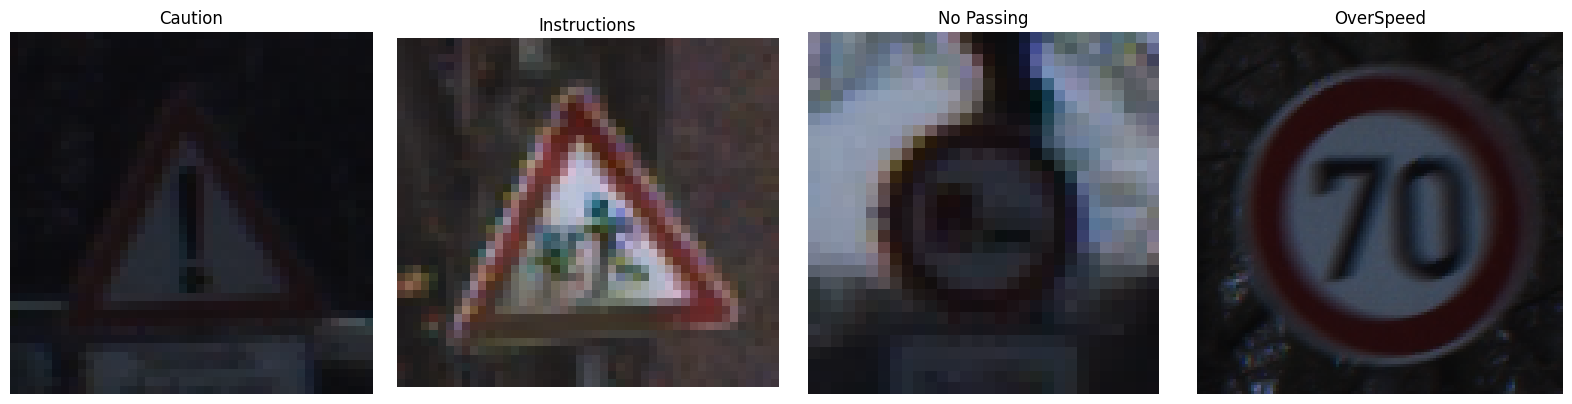

In [11]:
selected_images = []
selected_labels = []
class_names = sorted(os.listdir(train_dir))

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = num_classes
rows = 1
fig, axes = plt.subplots(rows, cols, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

## Part A: Designing and Analyzing CNNs from Scratch

### Seperate the Val and Train images

In [12]:
def split_dataset(source_dir, train_out, val_out, val_ratio=0.2, seed=123):
    random.seed(seed)
    for class_name in sorted(os.listdir(source_dir)):
        src_class = os.path.join(source_dir, class_name)
        if not os.path.isdir(src_class):
            continue
        images = [f for f in os.listdir(src_class)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)
        split_idx   = int(len(images) * (1 - val_ratio))
        train_imgs  = images[:split_idx]
        val_imgs    = images[split_idx:]
        for subset, imgs in [('train', train_imgs), ('val', val_imgs)]:
            dest = os.path.join(train_out if subset == 'train' else val_out, class_name)
            os.makedirs(dest, exist_ok=True)
            for img in imgs:
                shutil.copy2(os.path.join(src_class, img), os.path.join(dest, img))
        print(f"{class_name}: {len(train_imgs)} train, {len(val_imgs)} val")

TRAIN_SPLIT_DIR = "Traffic_Sign/train_split"
VAL_SPLIT_DIR   = "Traffic_Sign/val_split"

if not os.path.exists(TRAIN_SPLIT_DIR):
    split_dataset(train_dir, TRAIN_SPLIT_DIR, VAL_SPLIT_DIR)
else:
    print("Split directories already exist, skipping.")

Split directories already exist, skipping.


### Load Dataset

In [13]:
# Reuse the same image size and batch size for loading
img_height = 128
img_width  = 128
batch_size = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Load Dataset
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_SPLIT_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=False 
)

# Check for data leakage by comparing file paths beforeprefetching
train_files = set(train_ds_raw.file_paths)
val_files   = set(val_ds_raw.file_paths)
print(f"Overlapping files: {len(train_files & val_files)}") 

num_classes = len(train_ds_raw.class_names)
class_names = train_ds_raw.class_names
print("Classes:", class_names)
print("Num classes:", num_classes)

# Apply prefetch after the check
train_ds = train_ds_raw.prefetch(AUTOTUNE)
val_ds   = val_ds_raw.prefetch(AUTOTUNE)

Found 12691 files belonging to 4 classes.
Found 3176 files belonging to 4 classes.
Overlapping files: 0
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Num classes: 4


### Class weights

In [14]:
# balance classes using class weights
all_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_ds_raw])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.6379710893133712), 1: np.float64(1.396456866197183), 2: np.float64(0.7397411984145489), 3: np.float64(0.756677796327212)}


### Baseline model

In [15]:
baseline_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', use_bias=False,
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', use_bias=False,
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', use_bias=False,
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,812 (32.36 MB)

 Trainable params: 8,483,364 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

### Compile Baseline

In [16]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Early Stopping

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

### Train Baseline

In [18]:
start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 283ms/step - accuracy: 0.8964 - loss: 0.3319 - val_accuracy: 0.9153 - val_loss: 0.2808
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 139s 350ms/step - accuracy: 0.9812 - loss: 0.0745 - val_accuracy: 0.9865 - val_loss: 0.0563
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 146s 368ms/step - accuracy: 0.9914 - loss: 0.0453 - val_accuracy: 0.9962 - val_loss: 0.0321
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 187s 472ms/step - accuracy: 0.9945 - loss: 0.0344 - val_accuracy: 0.9962 - val_loss: 0.0258
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 138s 348ms/step - accuracy: 0.9929 - loss: 0.0368 - val_accuracy: 0.9953 - val_loss: 0.0278
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 169s 426ms/step - accuracy: 0.9942 - loss: 0.0303 - val_accuracy: 0.9950 - val_loss: 0.0362
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 217s 548ms/step - accuracy: 0.9931 - loss: 0.0336 - val_accuracy: 0.9943 - val_loss: 0.0304
Epoch 8/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 178s 449ms/step - accuracy: 0.9968 -

### Plot Baseline

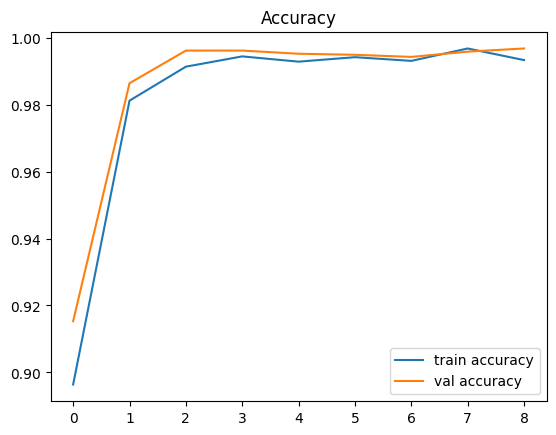

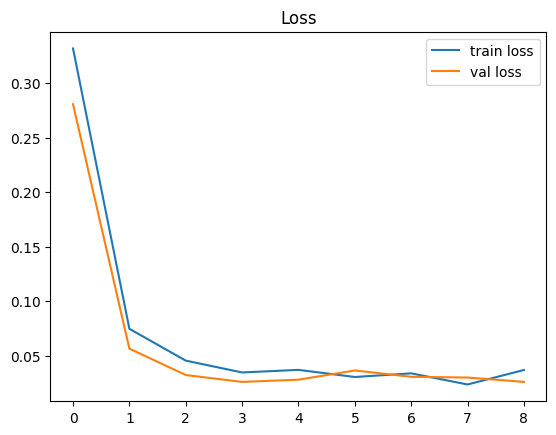

In [19]:
plt.plot(baseline_history.history['accuracy'], label='train accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(baseline_history.history['loss'], label='train loss')
plt.plot(baseline_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

### Evaluate Baseline Model


Classification Report:
              precision    recall  f1-score   support

     Caution       0.99      1.00      0.99       485
Instructions       1.00      0.99      0.99       569
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3176
   macro avg       1.00      1.00      1.00      3176
weighted avg       1.00      1.00      1.00      3176



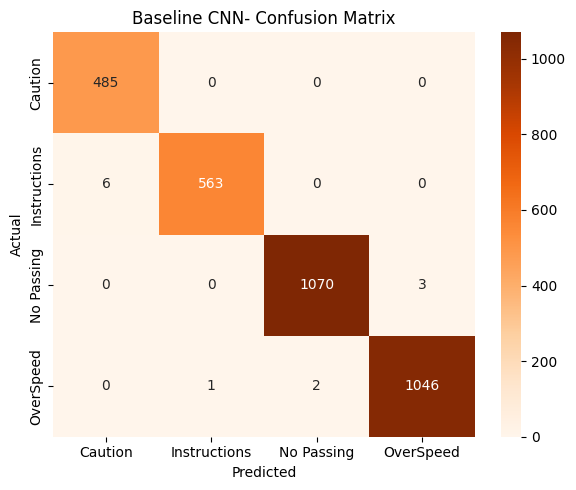

In [20]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = baseline_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline CNN- Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Data Augmentation

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

### Visualize Augmented Images

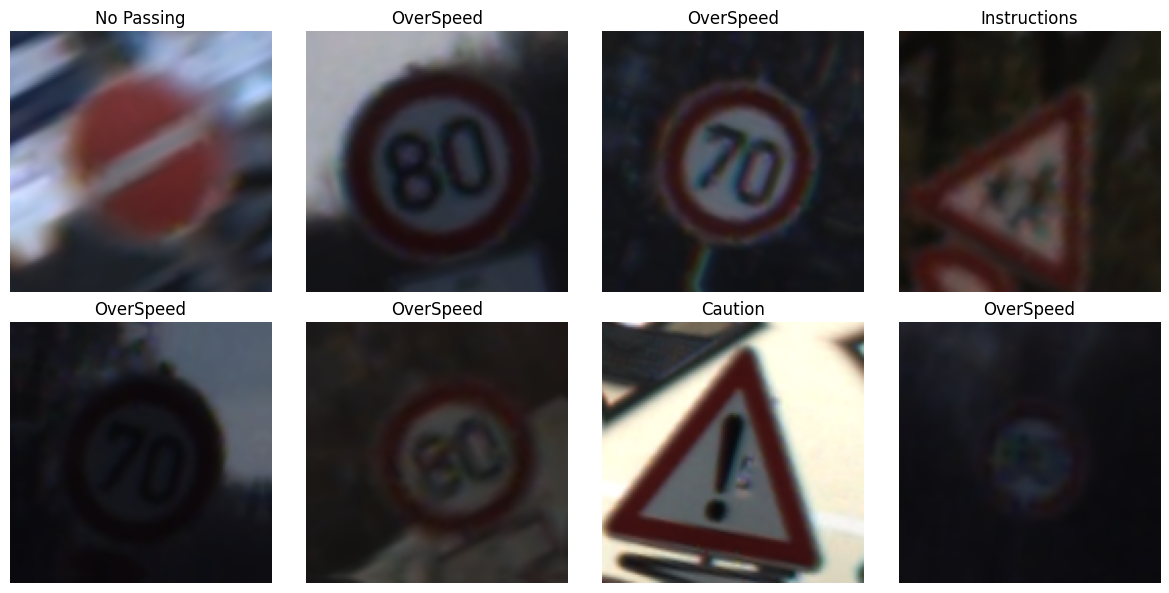

In [22]:
images, labels = next(iter(train_ds_aug))

plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Deeper Architecture with Regularization

In [23]:
deeper_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 6
    layers.Conv2D(1024, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,667,812 (25.44 MB)

 Trainable params: 6,663,780 (25.42 MB)

 Non-trainable params: 4,032 (15.75 KB)

### Compile Deeper Model

In [24]:
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Deeper Model (Adam)

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

deeper_start_time = time.time()
deeper_history = deeper_model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
deeper_train_time = time.time() - deeper_start_time
print(f"Deeper training time: {deeper_train_time:.2f} seconds")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 171s 418ms/step - accuracy: 0.7509 - loss: 0.6103 - val_accuracy: 0.7409 - val_loss: 0.5879
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 141s 355ms/step - accuracy: 0.9608 - loss: 0.1199 - val_accuracy: 0.9918 - val_loss: 0.0311
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 139s 349ms/step - accuracy: 0.9820 - loss: 0.0555 - val_accuracy: 0.9868 - val_loss: 0.0397
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 142s 357ms/step - accuracy: 0.9859 - loss: 0.0444 - val_accuracy: 0.9821 - val_loss: 0.0554
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 142s 357ms/step - accuracy: 0.9935 - loss: 0.0216 - val_accuracy: 0.9874 - val_loss: 0.0380
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 143s 360ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9972 - val_loss: 0.0087
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 148s 372ms/step - accuracy: 0.9943 - loss: 0.0182 - val_accuracy: 0.9943 - val_loss: 0.0193
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 146s 367ms/step - accuracy: 0.9954 -

### Plot deeper Model (Adam)

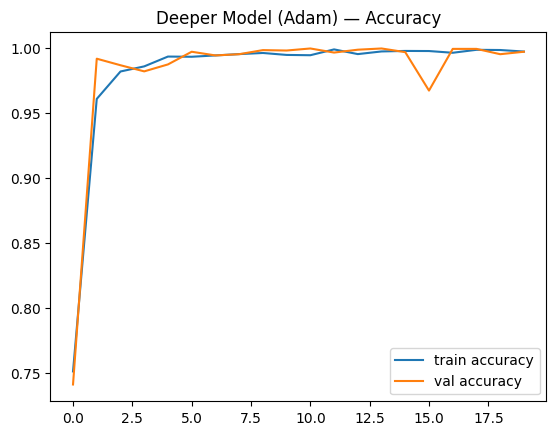

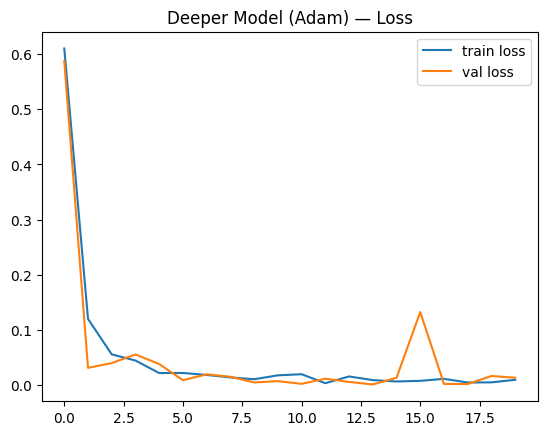

In [26]:
plt.plot(deeper_history.history['accuracy'], label='train accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Deeper Model (Adam) — Accuracy")
plt.show()

plt.plot(deeper_history.history['loss'], label='train loss')
plt.plot(deeper_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Deeper Model (Adam) — Loss")
plt.show()

### Evaluate Deeper Model (Adam)


Classification Report — Deeper Model (Adam):
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       485
Instructions       1.00      1.00      1.00       569
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3176
   macro avg       1.00      1.00      1.00      3176
weighted avg       1.00      1.00      1.00      3176



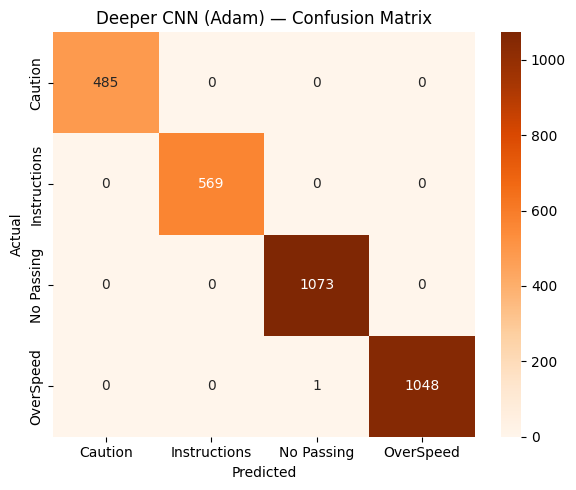

In [27]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = deeper_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report — Deeper Model (Adam):")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN (Adam) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### With SGD Optimizer

In [28]:
deeper_model_sgd = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 6
    layers.Conv2D(1024, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
deeper_model_sgd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,667,812 (25.44 MB)

 Trainable params: 6,663,780 (25.42 MB)

 Non-trainable params: 4,032 (15.75 KB)

### Train 

In [29]:
deeper_model_sgd.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_start_time = time.time()
deeper_history_sgd = deeper_model_sgd.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
sgd_train_time = time.time() - sgd_start_time
print(f"Deeper SGD training time: {sgd_train_time:.2f} seconds")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 129s 321ms/step - accuracy: 0.6907 - loss: 0.7141 - val_accuracy: 0.8416 - val_loss: 0.4549
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 129s 324ms/step - accuracy: 0.9199 - loss: 0.2308 - val_accuracy: 0.9726 - val_loss: 0.0862
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 129s 323ms/step - accuracy: 0.9643 - loss: 0.1142 - val_accuracy: 0.9839 - val_loss: 0.0437
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 127s 318ms/step - accuracy: 0.9783 - loss: 0.0630 - val_accuracy: 0.9896 - val_loss: 0.0280
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 126s 316ms/step - accuracy: 0.9856 - loss: 0.0438 - val_accuracy: 0.9953 - val_loss: 0.0175
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 127s 319ms/step - accuracy: 0.9912 - loss: 0.0287 - val_accuracy: 0.9962 - val_loss: 0.0103
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 128s 321ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9978 - val_loss: 0.0049
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 128s 322ms/step - accuracy: 0.9922 -

### Plot Deeper Model (SGD)

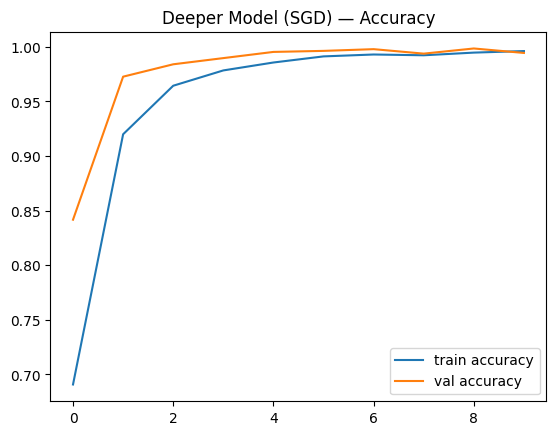

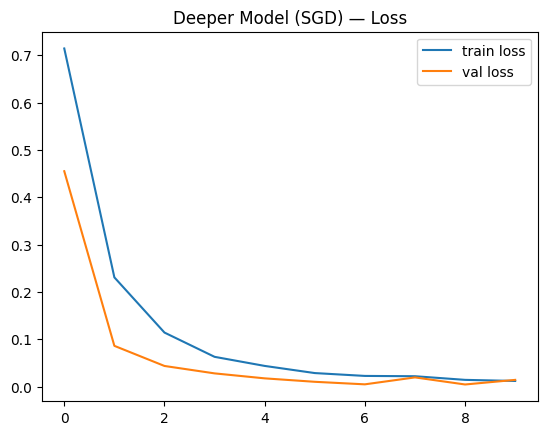

In [30]:
plt.plot(deeper_history_sgd.history['accuracy'], label='train accuracy')
plt.plot(deeper_history_sgd.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Deeper Model (SGD) — Accuracy")
plt.show()

plt.plot(deeper_history_sgd.history['loss'], label='train loss')
plt.plot(deeper_history_sgd.history['val_loss'], label='val loss')
plt.legend()
plt.title("Deeper Model (SGD) — Loss")
plt.show()

### Evaluate Deeper Model (SGD)


Classification Report — Deeper Model (SGD):
              precision    recall  f1-score   support

     Caution       0.61      0.99      0.76       485
Instructions       1.00      0.78      0.88       569
  No Passing       0.93      0.82      0.87      1073
   OverSpeed       0.87      0.83      0.85      1049

    accuracy                           0.84      3176
   macro avg       0.85      0.85      0.84      3176
weighted avg       0.87      0.84      0.85      3176



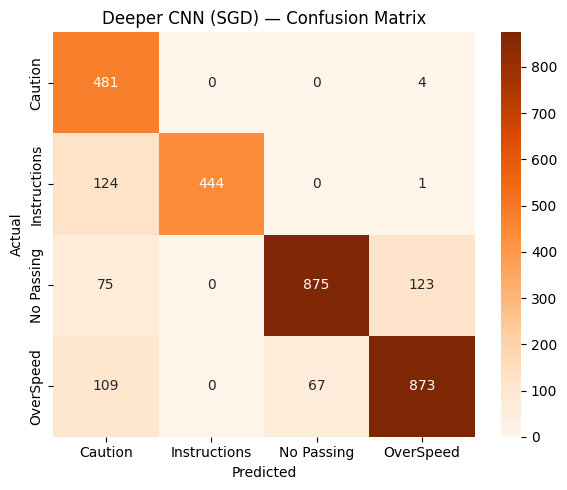

In [31]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = deeper_model_sgd.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report — Deeper Model (SGD):")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Deeper CNN (SGD) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### No Dropout training

In [ ]:
model_ablation = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),   # No Dropout
    layers.Dense(256, activation='relu'),   # No Dropout
    layers.Dense(128, activation='relu'),   # No Dropout
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name='Ablation_No_Dropout')

model_ablation.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_start = time.time()
history_ablation = model_ablation.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
ablation_time = time.time() - ablation_start
print(f"Ablation training time: {ablation_time:.2f}s")
print(f"Best Val Acc (No Dropout): {max(history_ablation.history['val_accuracy']):.4f}")
print(f"Best Val Acc (With Dropout): {max(deeper_history.history['val_accuracy']):.4f}")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 118s 289ms/step - accuracy: 0.7813 - loss: 0.5384 - val_accuracy: 0.6584 - val_loss: 0.9601
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 117s 294ms/step - accuracy: 0.9389 - loss: 0.1776 - val_accuracy: 0.9695 - val_loss: 0.0769
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 287ms/step - accuracy: 0.9689 - loss: 0.0934 - val_accuracy: 0.9704 - val_loss: 0.0811
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 287ms/step - accuracy: 0.9806 - loss: 0.0583 - val_accuracy: 0.9780 - val_loss: 0.0618
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 286ms/step - accuracy: 0.9872 - loss: 0.0413 - val_accuracy: 0.9817 - val_loss: 0.0433
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 287ms/step - accuracy: 0.9891 - loss: 0.0338 - val_accuracy: 0.9855 - val_loss: 0.0463
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 287ms/step - accuracy: 0.9887 - loss: 0.0300 - val_accuracy: 0.9991 - val_loss: 0.0070
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 287ms/step - accuracy: 0.9924 -

### Part B: Transfer Learning — MobileNetV2

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

tl_img_size = 96

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(tl_img_size, tl_img_size),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='training'
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(tl_img_size, tl_img_size),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='validation'
)

# Augmentation + MobileNetV2 preprocessing
data_aug_tl = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation_tl")

AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.map(
    lambda x, y: (data_aug_tl(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y))
val_ds_tl   = val_ds_tl.map(lambda x, y: (preprocess_input(x), y))

print("TL Dataset ready.")

Found 15867 files belonging to 4 classes.
Using 12694 files for training.
Found 15867 files belonging to 4 classes.
Using 3173 files for validation.
TL Dataset ready.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output, name='MobileNetV2_Transfer')

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_tl.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Early Stopping

In [ ]:
early_stop_tl = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Model Training

In [ ]:
tl_start_time = time.time()
history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stop_tl],
    class_weight=class_weights_dict
)
tl_train_time = time.time() - tl_start_time
print(f"Phase 1 (Feature Extraction) time: {tl_train_time:.2f} seconds")

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.8851 - loss: 0.3081 - val_accuracy: 0.9694 - val_loss: 0.0921
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9566 - loss: 0.1252 - val_accuracy: 0.9836 - val_loss: 0.0433
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9671 - loss: 0.0966 - val_accuracy: 0.9779 - val_loss: 0.0672
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9701 - loss: 0.0863 - val_accuracy: 0.9827 - val_loss: 0.0495
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9746 - loss: 0.0738 - val_accuracy: 0.9827 - val_loss: 0.0438
Phase 1 (Feature Extraction) time: 116.97 seconds


### Plot Transfer Learning (Phase 1)

In [ ]:
plt.plot(history_tl.history['accuracy'], label='train accuracy')
plt.plot(history_tl.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Transfer Learning (Feature Extraction) — Accuracy")
plt.show()

plt.plot(history_tl.history['loss'], label='train loss')
plt.plot(history_tl.history['val_loss'], label='val loss')
plt.legend()
plt.title("Transfer Learning (Feature Extraction) — Loss")
plt.show()

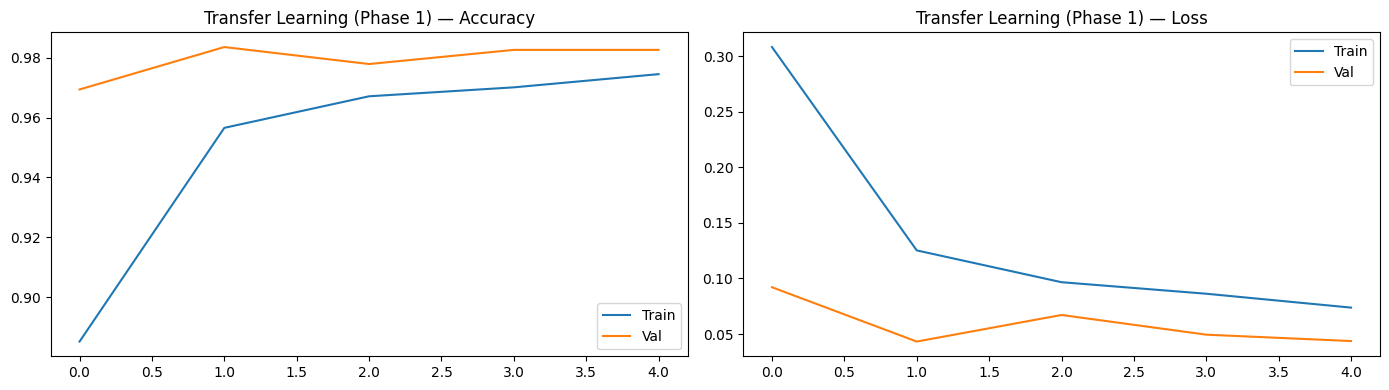

### Evaluate Transfer learning (Phase 1)

In [ ]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds_tl:
    preds = model_tl.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y_batch.numpy(),axis=1)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report — Transfer Learning (Feature Extraction):")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning (Feature Extraction) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Train trasnfer learning (phase 2)

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in model_tl.layers if l.trainable)}")

model_tl.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_start_time = time.time()
ft_history = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stop_tl],
    class_weight=class_weights_dict
)
ft_train_time = time.time() - ft_start_time
print(f"Phase 2 (Fine Tuning) time: {ft_train_time:.2f} seconds")
print(f"Best Val Acc: {max(ft_history.history['val_accuracy']):.4f}")

Trainable layers: 36
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.8615 - loss: 0.4554 - val_accuracy: 0.9801 - val_loss: 0.0555
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.9460 - loss: 0.1595 - val_accuracy: 0.9868 - val_loss: 0.0386
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9605 - loss: 0.1156 - val_accuracy: 0.9883 - val_loss: 0.0315
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.9698 - loss: 0.0914 - val_accuracy: 0.9905 - val_loss: 0.0280
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.9712 - loss: 0.0852 - val_accuracy: 0.9931 - val_loss: 0.0209
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.9791 - loss: 0.0566 - val_accuracy: 0.9937 - val_loss: 0.0212
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.9822 - loss: 0.0542 - val_accuracy: 0.9943 - val_loss: 0.0184
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.9

### plot Transfer learning (phase 2)

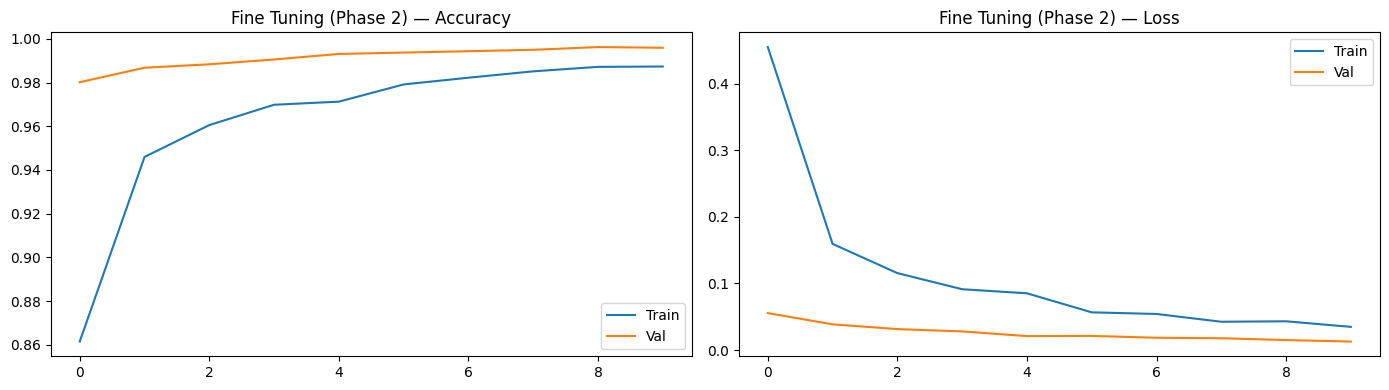

In [ ]:
plt.plot(ft_history.history['accuracy'], label='train accuracy')
plt.plot(ft_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Transfer Learning (Fine Tuning) — Accuracy")
plt.show()

plt.plot(ft_history.history['loss'], label='train loss')
plt.plot(ft_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Transfer Learning (Fine Tuning) — Loss")
plt.show()

### Evaluate Transfer Learning (Phase 2)

In [ ]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds_tl:
    preds = model_tl.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y_batch.numpy())
    
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report — Transfer Learning (Fine Tuning):")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning (Fine Tuning) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Final comparison between All models

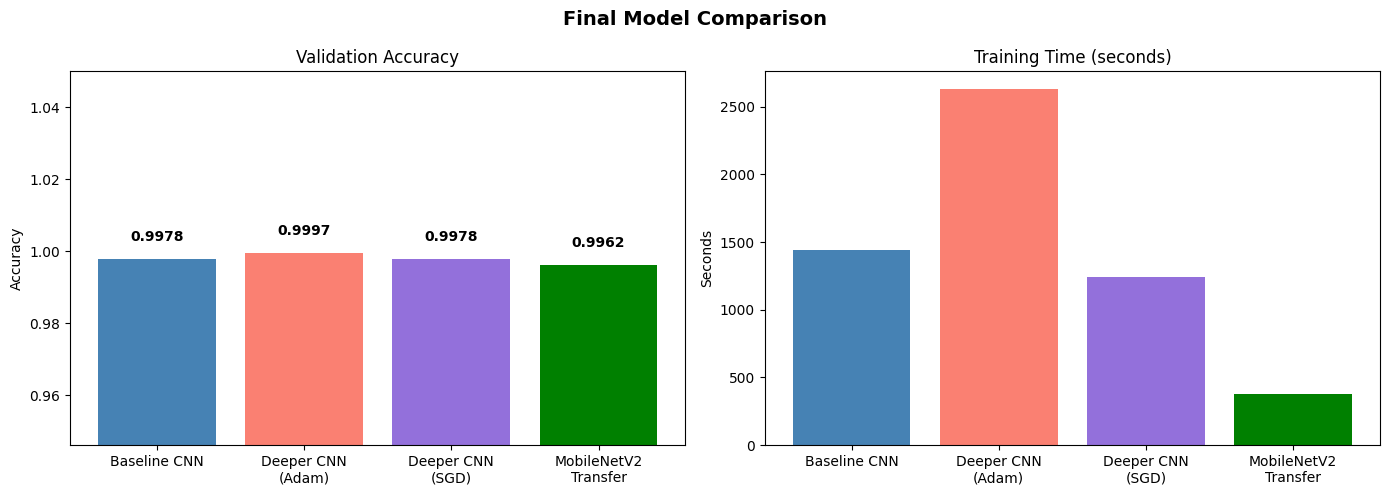


=== Final Model Summary ===
Model                     Val Acc      Train Time
-------------------------------------------------------
Baseline CNN              0.9978       1444.76s
Deeper CNN (Adam)         0.9997       2630.15s
Deeper CNN (SGD)          0.9978       1242.32s
MobileNetV2 Transfer      0.9962       380.90s


In [ ]:
baseline_acc = max(baseline_history.history['val_accuracy']) * 100
deeper_acc   = max(deeper_history.history['val_accuracy']) * 100
sgd_acc      = max(deeper_history_sgd.history['val_accuracy']) * 100
tl_acc       = max(ft_history.history['val_accuracy']) * 100

models = [
    'Baseline CNN',
    'Deeper CNN\n(Adam)',
    'Deeper CNN\n(SGD)',
    'MobileNetV2\nTransfer'
]

accuracies = [baseline_acc, deeper_acc, sgd_acc, tl_acc]

train_times = [
    baseline_train_time,
    deeper_train_time,
    sgd_train_time,
    tl_train_time + ft_train_time
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Model Comparison', fontsize=14, fontweight='bold')

# Accuracy
bars = axes[0].bar(
    models,
    accuracies,
    color=['steelblue', 'salmon', 'mediumpurple', 'green']
)

axes[0].set_ylim(min(accuracies) - 2, 101)
axes[0].set_title('Validation Accuracy')
axes[0].set_ylabel('Accuracy (%)')

for bar, acc in zip(bars, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{acc:.2f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Training Time
axes[1].bar(
    models,
    train_times,
    color=['steelblue', 'salmon', 'mediumpurple', 'green']
)

axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Seconds')

plt.tight_layout()
plt.show()

In [ ]:
# Summary Table
print("\n=== Final Model Summary ===")
print(f"{'Model':<25} {'Val Acc (%)':<15} {'Train Time'}")
print("-" * 60)

for name, acc, t in zip(models, accuracies, train_times):
    print(
        f"{name.replace(chr(10), ' '):<25} "
        f"{acc:.2f}%{'':<7} "
        f"{t:.2f}s"
    )